# Reservation cancellation risk and the design of a contact policy
## A graduate-level analysis of prediction, decision assumptions and external validity

**CIS 8005 · Research presentation notebook · October 2026**

**Research question.** Can reservation attributes rank cancellation risk well enough to justify testing a targeted confirmation-contact policy?

**Position.** The synthetic sample supports predictive discrimination. A contact policy still requires verified feature timing, an achievable workload and prospective evidence of intervention benefit.

This notebook pairs presentation sections with executable Python, statistical interpretation and discussion prompts. All empirical charts and tables below are generated by the visible code.

**Presentation route:** sections 1–12 cover the analysis and recommendation. The methods appendix supports technical questions. Read the rendered outputs for the narrative, and expand the code for a methods defense. Slideshow metadata marks narrative cells as slides and code cells as subslides.

**Reproducibility.** Outputs are embedded for reading without rerunning. To reproduce them, use a Python kernel with pandas, NumPy, matplotlib and scikit-learn. Set `ROOT` in the setup cell to the project folder containing `data/raw/train.csv`. The full labeled sample and the previous random holdout have already been examined in earlier work. This is a reproducible extension of that analysis, not a new confirmatory experiment.

## 1. Research design and scope of inference

We estimate the retrospective association

$$p(x)=P(Y=1\mid X=x),\qquad Y=1\text{ denotes cancellation.}$$

The unit of analysis is one **synthetic reservation record**. A proposed hotel decision is whether to contact a reservation at a specified scoring time. The data do not contain verified feature histories, contact assignments or treatment outcomes.

| Claim | What the data support | What remains unmeasured |
|---|---|---|
| Prediction | Ranking observed cancellations within this sample | Performance on genuinely new hotel bookings |
| Probability estimation | Reliability diagnostics on reserved rows | Stability after a change in hotel or period |
| Decision policy | Workload and error penalties under explicit assumptions | Actual staffing costs and intervention effects |
| Causal benefit | A prospective study design | Cancellations prevented or revenue recovered |

**Working assumption:** score at booking creation. Historical outcome counts and special requests are eligible only if their recorded values existed then. This assumption is unresolved in the source data.

In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance



# Change ROOT if you move the project to another computer.
ROOT = Path(r'C:\Users\jalen\Desktop\workspace\cancellations')
OUT = Path.cwd() / 'graduate_results'
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
COLORS = {'navy': '#15344A', 'teal': '#167E88', 'amber': '#B46721',
          'gray': '#647780', 'light': '#E6EEF2'}
plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 170, 'font.size': 12,
    'axes.titlesize': 15, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlepad': 14,
})
pd.set_option('display.max_columns', 20)

def finish(fig, filename):
    """Save the evidence figure and display it inside the notebook."""
    fig.savefig(OUT / filename, bbox_inches='tight')
    plt.show()

raw = pd.read_csv(ROOT / 'data/raw/train.csv')
assert raw['booking_status'].isin([0, 1]).all()
assert raw['id'].is_unique
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'sklearn': sklearn.__version__}
print('Environment:', versions)
print(f'Raw data: {raw.shape[0]:,} rows and {raw.shape[1]} columns')
(OUT / 'versions.json').write_text(json.dumps(versions, indent=2))

Environment: {'python': '3.14.6', 'numpy': '2.5.3', 'pandas': '3.0.6', 'sklearn': '1.9.1'}
Raw data: 42,100 rows and 19 columns


87

**Code explanation.** `Path` handles filenames without manual slash concatenation. `read_csv` loads the raw observations into a DataFrame. Assertions stop execution if key assumptions fail. `SEED` makes the randomized operations reproducible. `finish` saves a figure and embeds it in the notebook. Version recording makes the computational environment explicit.

The variable `raw` contains all labeled observations. The training partition will be created later. No competition test labels are available, so the competition test file cannot support metrics.

## 2. Data quality and defensible transformation

The source is Kaggle Playground Series S3E7. Project documentation identifies these data as synthetic records generated from an earlier reservation dataset. Numerical category codes have no verified business-label mapping in this project.

**Cleaning principle:** preserve uncertain observations and expose their condition. Deleting every zero-price or invalid-date row would impose an unsupported interpretation of how the records arose.

The code reproduces notebook 00 directly from the raw file, so this presentation does not depend on running another notebook first.

,condition,count
0,Missing cells,0
1,Duplicates excluding ID,0
2,invalid_arrival_date,50
3,zero_guests,16
4,zero_nights,114
5,zero_room_price,641


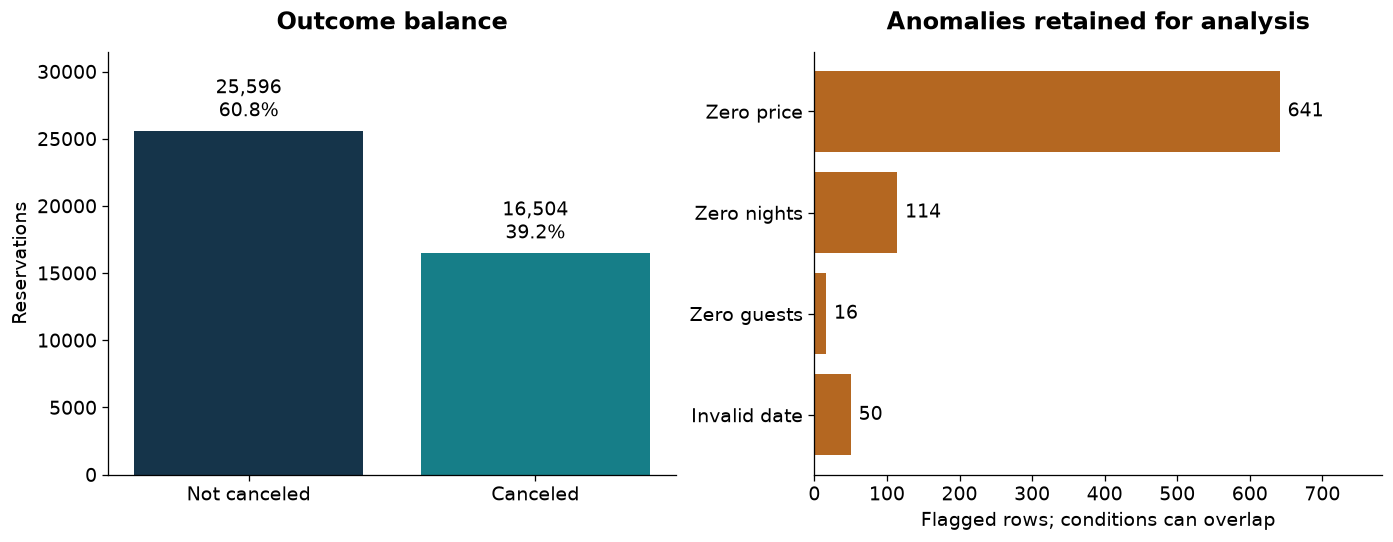

In [2]:
def add_features(frame):
    frame = frame.copy()
    frame['total_guests'] = frame.no_of_adults + frame.no_of_children
    frame['total_nights'] = frame.no_of_weekend_nights + frame.no_of_week_nights
    arrival = pd.to_datetime({'year': frame.arrival_year,
                             'month': frame.arrival_month,
                             'day': frame.arrival_date}, errors='coerce')
    frame['invalid_arrival_date'] = arrival.isna().astype(int)
    frame['zero_guests'] = frame.total_guests.eq(0).astype(int)
    frame['zero_nights'] = frame.total_nights.eq(0).astype(int)
    frame['zero_room_price'] = frame.avg_price_per_room.eq(0).astype(int)
    return frame

train = add_features(raw)
assert train[raw.columns].equals(raw)  # Original values remain unchanged.
y = train['booking_status'].astype(int)
X = train.drop(columns=['id', 'booking_status'])
categories = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
flags = ['invalid_arrival_date', 'zero_guests', 'zero_nights', 'zero_room_price']
audit = pd.DataFrame({'condition': ['Missing cells', 'Duplicates excluding ID', *flags],
                     'count': [raw.isna().sum().sum(), raw.drop(columns='id').duplicated().sum(),
                               *train[flags].sum().tolist()]})
display(audit)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
counts = y.value_counts().reindex([0, 1])
bars = axes[0].bar(['Not canceled', 'Canceled'], counts,
                   color=[COLORS['navy'], COLORS['teal']])
axes[0].bar_label(bars, labels=[f'{n:,}\n{n/len(y):.1%}' for n in counts], padding=5)
axes[0].set_ylim(0, counts.max()*1.23)
axes[0].set_ylabel('Reservations')
axes[0].set_title('Outcome balance')
flag_counts = train[flags].sum()
bars = axes[1].barh(['Invalid date', 'Zero guests', 'Zero nights', 'Zero price'],
                    flag_counts, color=COLORS['amber'])
axes[1].bar_label(bars, padding=5)
axes[1].set_xlim(0, flag_counts.max()*1.22)
axes[1].set_xlabel('Flagged rows; conditions can overlap')
axes[1].set_title('Anomalies retained for analysis')
finish(fig, '01_data_audit.png')

**Interpretation.** The target is moderately imbalanced: the majority-class accuracy is approximately 60.8%. This makes accuracy alone insufficient. The anomaly counts overlap and must not be added to obtain a unique-row total.

**Code explanation.** `errors='coerce'` converts impossible dates to `NaT`; `.isna().astype(int)` turns that condition into a binary feature. `.copy()` avoids modifying the input object. Deterministic sums and flags do not learn parameters from outcomes. We evaluate their predictive contribution later.

## 3. Descriptive evidence and uncertainty

Lead time has a strong observed relationship with cancellation. We show counts alongside rates and Wilson intervals to avoid presenting small groups as equally precise.

These intervals are **binomial summaries under an independent-observation assumption**. Synthetic generation, unobserved dependence and selection limit their interpretation as population uncertainty. They do not account for confounding.

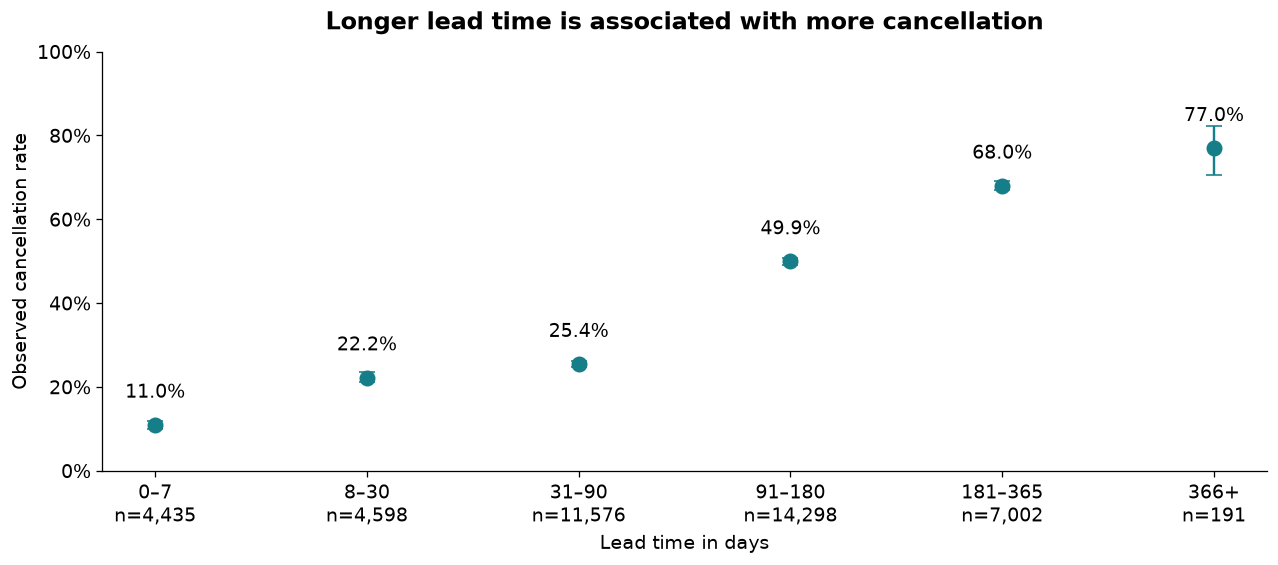

,n,canceled,rate
lead_time,,,
0–7,4435,486,0.1096
8–30,4598,1023,0.2225
31–90,11576,2946,0.2545
91–180,14298,7141,0.4994
181–365,7002,4761,0.6799
366+,191,147,0.7696


In [3]:
def wilson(successes, n, z=1.96):
    """Wilson interval for a binomial proportion, assuming independent rows."""
    rate = successes / n
    denom = 1 + z*z/n
    center = (rate + z*z/(2*n)) / denom
    half = z*np.sqrt(rate*(1-rate)/n + z*z/(4*n*n)) / denom
    return center-half, center+half

lead_band = pd.cut(train.lead_time, [-1, 7, 30, 90, 180, 365, np.inf],
                   labels=['0–7', '8–30', '31–90', '91–180', '181–365', '366+'])
lead = train.groupby(lead_band, observed=True).booking_status.agg(
    n='size', canceled='sum', rate='mean')
lo, hi = wilson(lead.canceled, lead.n)
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
positions = np.arange(len(lead))
ax.errorbar(positions, lead.rate, yerr=[lead.rate-lo, hi-lead.rate],
            fmt='o', markersize=9, capsize=5, color=COLORS['teal'])
ax.set_xticks(positions, [f'{label}\nn={n:,}' for label, n in zip(lead.index, lead.n)])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('Lead time in days')
ax.set_ylabel('Observed cancellation rate')
ax.set_title('Longer lead time is associated with more cancellation')
for i, rate in enumerate(lead.rate):
    ax.annotate(f'{rate:.1%}', (i, rate), xytext=(0, 17),
                textcoords='offset points', ha='center')
finish(fig, '02_lead_time_uncertainty.png')
display(lead.round(4))

**Discussion.** Cancellation increases from approximately 11% for 0–7 days to 68% for 181–365 days. The 366+ day group has only 191 rows. Price, market segment, calendar period and guest behavior may confound these comparisons. The next stage assesses multivariable prediction rather than assigning a causal effect to lead time.

**Code explanation.** `pd.cut` applies fixed descriptive bins. `groupby(...).agg(...)` calculates counts and rates per bin. Wilson intervals remain within valid probability limits and behave better than a simple symmetric normal interval near 0 or 1.

## 4. Validation architecture and leakage controls

We preserve the previous analysis design: 60% fitting, 20% threshold validation and 20% final random holdout, with stratification on the outcome. Three-fold cross-validation inside the fitting partition compares model families.

**Disclosure:** prior EDA inspected all labeled rows, and earlier work already evaluated this holdout. Reproducing these results does not create a new untouched test set. Additional threshold and capacity plots below are exploratory validation analyses, with no new policy selected on holdout outcomes.

Preprocessing belongs inside each training fold. Category encoding, imputation and scaling must learn from that fold's fitting rows only.

,partition,rows,cancellation_rate
0,training,25260,0.392003
1,validation,8420,0.392043
2,holdout,8420,0.392043


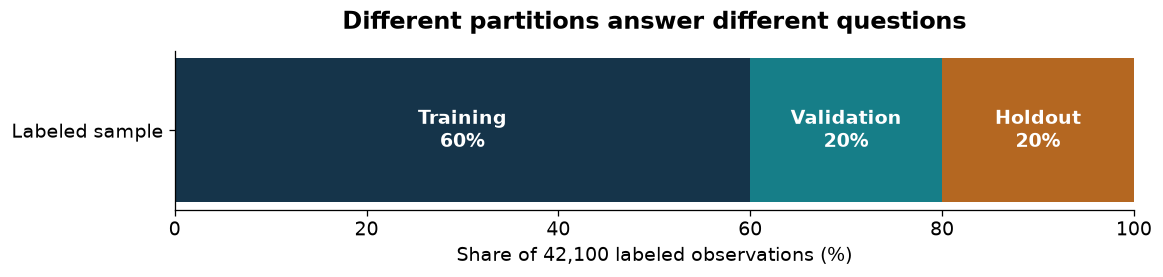

In [4]:
X_dev, X_hold, y_dev, y_hold = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
assert set(X_fit.index).isdisjoint(X_val.index)
assert set(X_dev.index).isdisjoint(X_hold.index)
split_summary = pd.DataFrame([
    {'partition': name, 'rows': len(labels), 'cancellation_rate': labels.mean()}
    for name, labels in [('training', y_fit), ('validation', y_val), ('holdout', y_hold)]
])
display(split_summary)
split_summary.to_csv(OUT / 'split_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 2.3), constrained_layout=True)
left = 0
for name, amount, color in [('Training', 60, COLORS['navy']),
                             ('Validation', 20, COLORS['teal']),
                             ('Holdout', 20, COLORS['amber'])]:
    ax.barh(['Labeled sample'], [amount], left=left, color=color, height=0.45)
    ax.text(left+amount/2, 0, f'{name}\n{amount}%', ha='center', va='center', color='white', weight='bold')
    left += amount
ax.set_xlim(0, 100)
ax.set_xlabel('Share of 42,100 labeled observations (%)')
ax.set_title('Different partitions answer different questions')
finish(fig, '03_validation_design.png')

**Code explanation.** The second split reserves 25% of the remaining 80%, producing 20% of the original file for validation. `stratify` approximately preserves outcome prevalence. The assertions check that row-index sets do not overlap. The competition's unlabeled file never enters the evaluation.

## 5. Model specification and comparison

We compare a prevalence-only baseline with regularized logistic regression, a depth-limited decision tree and a random forest. Logistic regression offers an additive relationship on the log-odds scale. Trees can capture nonlinear thresholds and interactions. The forest averages across randomized trees to reduce instability.

**Selection criterion:** mean training-fold average precision (AP). AP is a recall-weighted summary of precision, not accuracy and not the same as trapezoidal PR area. Its baseline depends on prevalence. Fixed hyperparameters limit the search but do not establish the best possible model.

| Choice | Reason | Limitation |
|---|---|---|
| One-hot category encoding | Avoid unsupported numerical ordering | More columns, unknown levels need handling |
| Numeric standardization | Makes logistic regularization more comparable across scales | Does not make effects causal |
| Minimum tree leaf sizes | Restricts very small terminal groups | Hyperparameters are illustrative |
| Three stratified folds | Applies a common comparison design | Fold scores are correlated, with limited precision |

In [5]:
from sklearn.metrics import make_scorer

def make_preprocessor(columns):
    cats = [c for c in categories if c in columns]
    nums = [c for c in columns if c not in cats]
    return ColumnTransformer([
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), nums),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cats),
    ])

def make_model(estimator, columns):
    return Pipeline([('prepare', make_preprocessor(columns)),
                     ('model', clone(estimator))])

estimators = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logistic regression': LogisticRegression(max_iter=3000, C=1.0),
    'Decision tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=30,
                                           random_state=SEED),
    'Random forest': RandomForestClassifier(n_estimators=150,
        min_samples_leaf=5, max_features='sqrt', random_state=SEED, n_jobs=1),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {'roc_auc': 'roc_auc', 'average_precision': 'average_precision',
           'recall': 'recall', 'precision': make_scorer(precision_score, zero_division=0),
           'neg_brier': 'neg_brier_score'}

**Code explanation.** `ColumnTransformer` sends different columns through different transformations. `Pipeline` joins preprocessing to the estimator, so cross-validation refits the whole procedure. `clone` creates an unfitted copy. `C=1.0` sets inverse regularization strength in logistic regression. `min_samples_leaf` restricts small leaves. The custom precision scorer returns zero when a model predicts no positive cases, which occurs for the dummy baseline.

,mean_AP,sd_AP,mean_ROC_AUC,mean_precision_at_0.5,mean_recall_at_0.5,mean_Brier
model,,,,,,
Random forest,0.830374,0.002447,0.883957,0.788245,0.721672,0.134304
Decision tree,0.791281,0.004424,0.860172,0.768322,0.713796,0.144302
Logistic regression,0.767816,0.007620,0.843196,0.726434,0.682589,0.156366
Dummy,0.392003,0.000069,0.500000,0.000000,0.000000,0.238337


Selected by training CV: Random forest


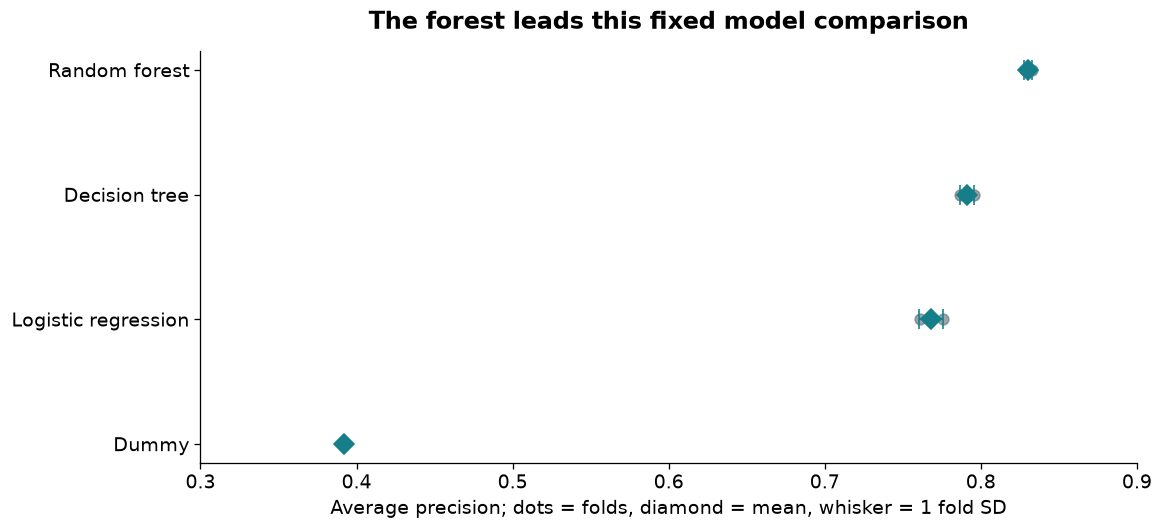

In [6]:
cv_rows = []
fold_scores = {}
for name, estimator in estimators.items():
    result = cross_validate(make_model(estimator, X.columns), X_fit, y_fit,
                            cv=cv, scoring=scoring, n_jobs=1)
    fold_scores[name] = result['test_average_precision']
    cv_rows.append({
        'model': name,
        'mean_AP': result['test_average_precision'].mean(),
        'sd_AP': result['test_average_precision'].std(ddof=1),
        'mean_ROC_AUC': result['test_roc_auc'].mean(),
        'mean_precision_at_0.5': result['test_precision'].mean(),
        'mean_recall_at_0.5': result['test_recall'].mean(),
        'mean_Brier': -result['test_neg_brier'].mean(),
    })
comparison = pd.DataFrame(cv_rows).set_index('model').sort_values('mean_AP', ascending=False)
display(comparison)
comparison.to_csv(OUT / 'training_cv_comparison.csv')
winner = comparison.drop(index='Dummy')['mean_AP'].idxmax()
best = make_model(estimators[winner], X.columns).fit(X_fit, y_fit)
print('Selected by training CV:', winner)
p_val = best.predict_proba(X_val)[:, 1]

order = comparison.index[::-1]
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for j, name in enumerate(order):
    scores = fold_scores[name]
    ax.scatter(scores, np.full(len(scores), j), color=COLORS['gray'], alpha=.65, s=45)
    ax.errorbar(scores.mean(), j, xerr=scores.std(ddof=1), fmt='D',
                color=COLORS['teal'], capsize=6, markersize=9)
ax.set_yticks(range(len(order)), order)
ax.set_xlim(.3, .9)
ax.set_xlabel('Average precision; dots = folds, diamond = mean, whisker = 1 fold SD')
ax.set_title('The forest leads this fixed model comparison')
finish(fig, '04_model_comparison.png')

**Interpretation.** The recorded ordering is random forest, decision tree, logistic regression and dummy baseline. Use the recomputed table above as the numerical source. Fold standard deviations describe variation across these folds, not confidence intervals or a formal test of superiority.

**Code explanation.** `test_average_precision` refers to each internal cross-validation evaluation fold. It does not refer to the final holdout. `idxmax` returns the winning model name. `predict_proba(... )[:, 1]` extracts the cancellation probability. The selected pipeline then fits all 25,260 fitting rows.

## 6. Discrimination and probability reliability

ROC and precision-recall curves evaluate ranking across possible cutoffs. A reliability plot compares average predicted risk with the observed fraction canceled within bins.

**Interpretive distinction:** Brier score measures overall probability error and reflects both calibration and discrimination. A lower Brier score alone does not establish better calibration. No probability-calibration model is fitted here.

Reference: [scikit-learn probability calibration](https://scikit-learn.org/stable/modules/calibration.html).

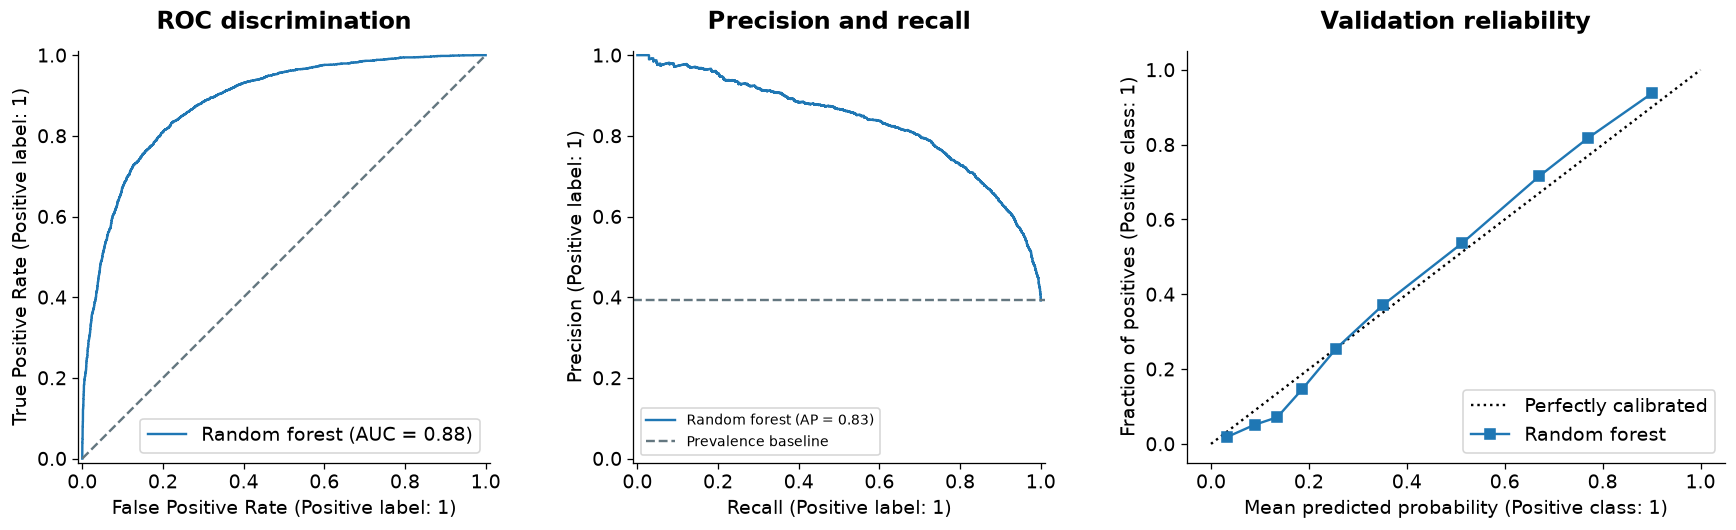

Validation Brier score: 0.1339


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
RocCurveDisplay.from_predictions(y_val, p_val, ax=axes[0], name=winner)
axes[0].plot([0, 1], [0, 1], '--', color=COLORS['gray'], label='Random ranking')
axes[0].set_title('ROC discrimination')
PrecisionRecallDisplay.from_predictions(y_val, p_val, ax=axes[1], name=winner)
axes[1].axhline(y_val.mean(), ls='--', color=COLORS['gray'], label='Prevalence baseline')
axes[1].legend(fontsize=9)
axes[1].set_title('Precision and recall')
CalibrationDisplay.from_predictions(y_val, p_val, n_bins=10, strategy='quantile',
                                   ax=axes[2], name=winner)
axes[2].set_title('Validation reliability')
finish(fig, '05_probability_diagnostics.png')
print(f'Validation Brier score: {brier_score_loss(y_val, p_val):.4f}')

**Code explanation.** `strategy='quantile'` creates roughly equally populated risk bins. The diagonal in the reliability plot represents equality between predicted and observed risk. Binning can hide within-bin miscalibration. Any subsequent recalibration would need training-only fitting and a renewed validation procedure before a genuinely new final evaluation.

## 7. Decision thresholds encode assumptions

For an alert rule $a_t(x)=\mathbf{1}[p(x)\ge t]$, the illustrative empirical loss is

$$L(t)=C_{FP}\,FP(t)+C_{FN}\,FN(t).$$

The original policy uses $C_{FP}=1$ and $C_{FN}=5$. These are **assumed error penalties**, not money, prevented cancellations or measured contact benefits. Correct classifications carry zero loss in this simplified model.

If probabilities were perfectly calibrated and those were the true constant losses, the theoretical cutoff would be

$$t^*=\frac{C_{FP}}{C_{FP}+C_{FN}}=\frac{1}{6}\approx0.167.$$

We retain the empirically selected validation cutoff from the same grid search as the companion. Finite data and probability errors can make that cutoff differ from the idealized value. The additional ratios below show sensitivity to assumptions and do not create a new holdout-selected policy.

,chosen validation policy
threshold,0.210000
FP,2048.000000
FN,226.000000
alert_rate,0.608432
loss,3178.000000


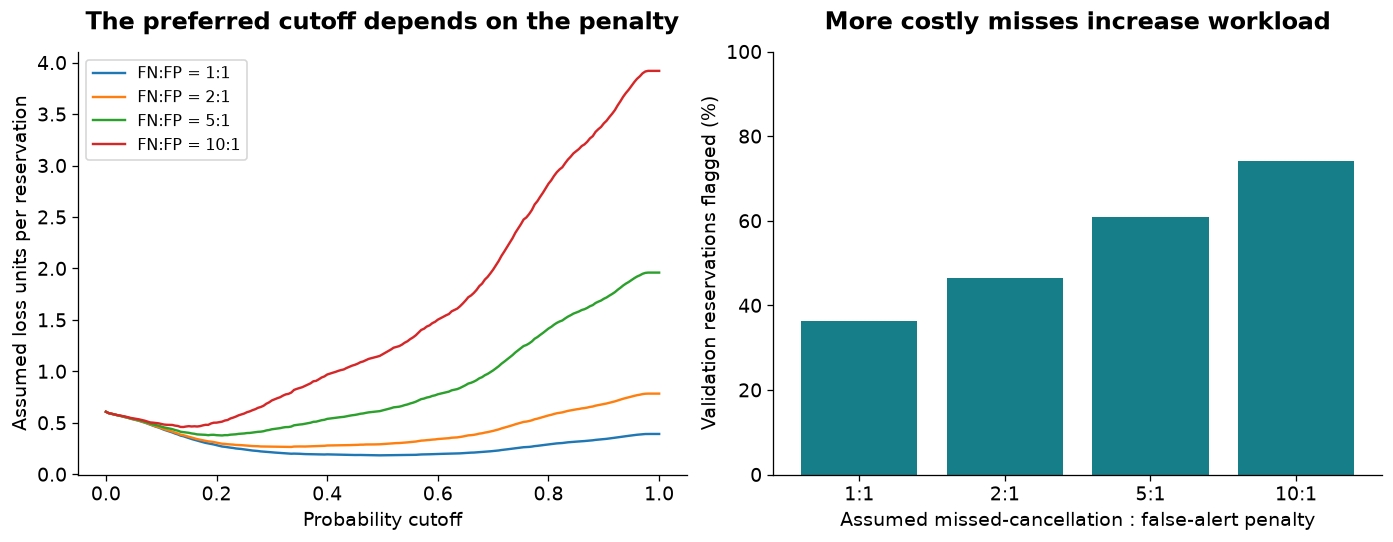

,FN:FP penalty,validation cutoff,validation alert rate
0,1:1,0.49,0.363
1,2:1,0.33,0.464
2,5:1,0.21,0.608
3,10:1,0.14,0.742


In [8]:
def metric_row(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, zero_division=0),
        'recall': recall_score(labels, predictions, zero_division=0),
        'F1': f1_score(labels, predictions, zero_division=0),
        'ROC_AUC': roc_auc_score(labels, probabilities),
        'AP': average_precision_score(labels, probabilities),
        'Brier': brier_score_loss(labels, probabilities),
        'alert_rate': predictions.mean(), 'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp),
    }

thresholds = np.r_[np.linspace(0, 1, 201), np.nextafter(1.0, 2.0)]
threshold_rows = []
for t in thresholds:
    pred = p_val >= t
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    threshold_rows.append({'threshold': t, 'FP': fp, 'FN': fn,
                           'alert_rate': pred.mean(), 'loss': fp + 5 * fn})
threshold_table = pd.DataFrame(threshold_rows)
# For tied loss, prefer fewer contacts.
chosen = threshold_table.sort_values(['loss', 'alert_rate']).iloc[0]
threshold = float(chosen['threshold'])
display(chosen.to_frame('chosen validation policy'))
threshold_table.to_csv(OUT / 'validation_thresholds.csv', index=False)

ratios = [1, 2, 5, 10]
cost_sensitivity = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ratio in ratios:
    curve = threshold_table.FP + ratio * threshold_table.FN
    selected = (threshold_table.assign(scenario_loss=curve)
                .sort_values(['scenario_loss', 'alert_rate']).iloc[0])
    cost_sensitivity.append({'FN:FP penalty': f'{ratio}:1',
                             'validation cutoff': selected.threshold,
                             'validation alert rate': selected.alert_rate})
    axes[0].plot(threshold_table.threshold, curve/len(y_val), label=f'FN:FP = {ratio}:1')
axes[0].set_xlabel('Probability cutoff')
axes[0].set_ylabel('Assumed loss units per reservation')
axes[0].set_title('The preferred cutoff depends on the penalty')
axes[0].legend(fontsize=10)
scenario = pd.DataFrame(cost_sensitivity)
axes[1].bar(scenario['FN:FP penalty'], 100*scenario['validation alert rate'], color=COLORS['teal'])
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Assumed missed-cancellation : false-alert penalty')
axes[1].set_ylabel('Validation reservations flagged (%)')
axes[1].set_title('More costly misses increase workload')
finish(fig, '06_cost_assumptions.png')
display(scenario.round(3))

**Code explanation.** `np.linspace` creates candidate cutoffs. `np.nextafter(1.0, 2.0)` includes a cutoff above one to represent alerting nobody. `confusion_matrix(...).ravel()` returns TN, FP, FN and TP. Sorting by loss and then alert rate breaks loss ties in favor of less work. `zero_division=0` handles undefined precision when nobody is alerted.

**Decision implication.** A threshold cannot be called optimal without specifying the objective and constraints. The chosen 5:1 ratio is a scenario, not a discovered property of hotel operations.

## 8. Capacity constraints and risk prioritization

A fixed probability threshold can produce more alerts than staff can process. A capacity policy instead ranks reservations and reviews only the highest-risk fraction of an eligible cohort.

The following **exploratory validation analysis** compares recall, precision and cumulative gains at different capacities. It assumes all reservations in the cohort can be ranked together and contacts have equal resource cost. In practice, cohorts should reflect daily eligible bookings, and benefit may vary independently of cancellation risk.

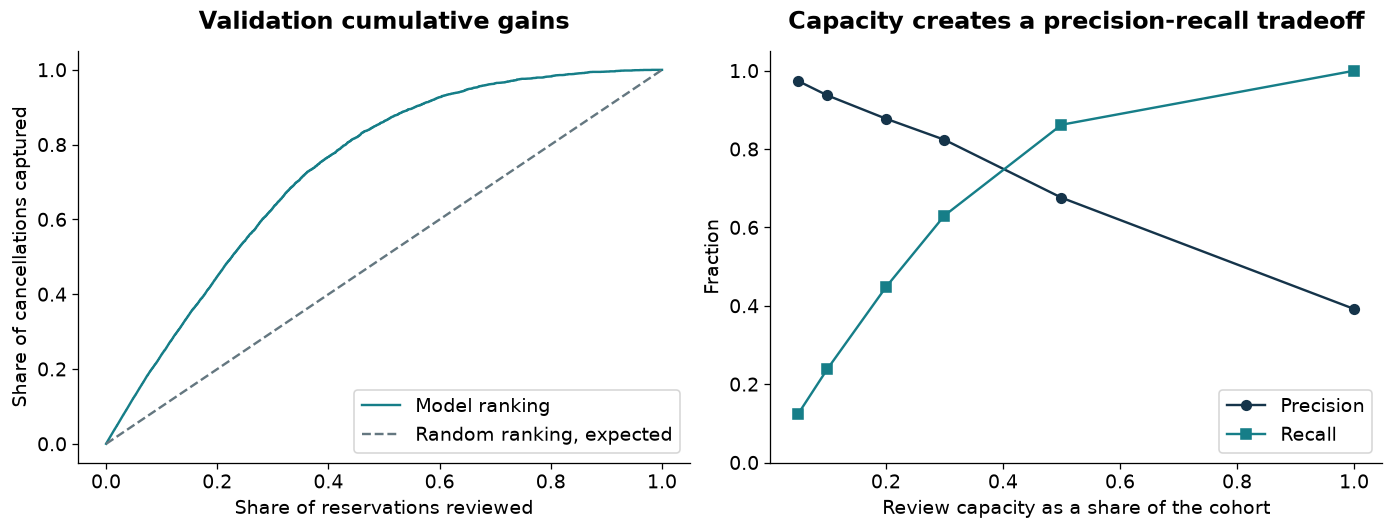

,review share,contacts,precision,recall,lift over random
0,0.05,421,0.974,0.124,2.484
1,0.10,842,0.937,0.239,2.390
2,0.20,1684,0.878,0.448,2.239
3,0.30,2526,0.824,0.630,2.101
4,0.50,4210,0.676,0.862,1.724
5,1.00,8420,0.392,1.000,1.000


In [9]:
# Stable sorting makes ties reproducible. This is a batch ranking illustration.
ranked = np.argsort(-p_val, kind='stable')
capacity_rows = []
for fraction in [.05, .10, .20, .30, .50, 1.0]:
    k = max(1, int(np.ceil(fraction*len(y_val))))
    caught = y_val.to_numpy()[ranked[:k]].sum()
    capacity_rows.append({'review share': k/len(y_val), 'contacts': k,
                          'precision': caught/k, 'recall': caught/y_val.sum(),
                          'lift over random': (caught/k)/y_val.mean()})
capacity = pd.DataFrame(capacity_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
review_share = np.arange(1, len(y_val)+1)/len(y_val)
cumulative_recall = np.cumsum(y_val.to_numpy()[ranked])/y_val.sum()
axes[0].plot(review_share, cumulative_recall, color=COLORS['teal'], label='Model ranking')
axes[0].plot([0,1], [0,1], '--', color=COLORS['gray'], label='Random ranking, expected')
axes[0].set(xlabel='Share of reservations reviewed', ylabel='Share of cancellations captured',
            title='Validation cumulative gains')
axes[0].legend()
axes[1].plot(capacity['review share'], capacity.precision, 'o-', label='Precision', color=COLORS['navy'])
axes[1].plot(capacity['review share'], capacity.recall, 's-', label='Recall', color=COLORS['teal'])
axes[1].set(xlabel='Review capacity as a share of the cohort', ylabel='Fraction', ylim=(0,1.05),
            title='Capacity creates a precision-recall tradeoff')
axes[1].legend()
finish(fig, '07_capacity_tradeoffs.png')
display(capacity.round(3))
capacity.to_csv(OUT/'validation_capacity.csv', index=False)

**Code explanation.** `argsort(-p_val)` returns row positions ordered from highest to lowest risk. `ceil` rounds the allowed number of contacts upward. Precision counts cancellations among reviewed bookings; recall counts reviewed cancellations among all observed cancellations. Lift divides precision by cohort prevalence.

**Assumption check.** Capturing a cancellation in a ranked list does not mean preventing it. Choosing who benefits most from contact requires treatment-effect evidence. No capacity setting in this figure has been prospectively validated.

## 9. Interpretation and sensitivity to feature availability

Permutation importance measures the deterioration in predictive performance when a feature is shuffled. It describes model reliance within the evaluation sample. Correlated predictors can substitute for one another, so feature importance is not a decomposition of causal effects.

For a consistent baseline, we first select a reproducible 3,000-row validation subset, then perform every importance evaluation on that same subset. This implementation is more directly comparable across permutations than mixing a full-sample baseline with subsampled scores. It can differ slightly from the earlier companion's numerical importance values.

Reference: [scikit-learn on correlated predictors and permutation importance](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html).

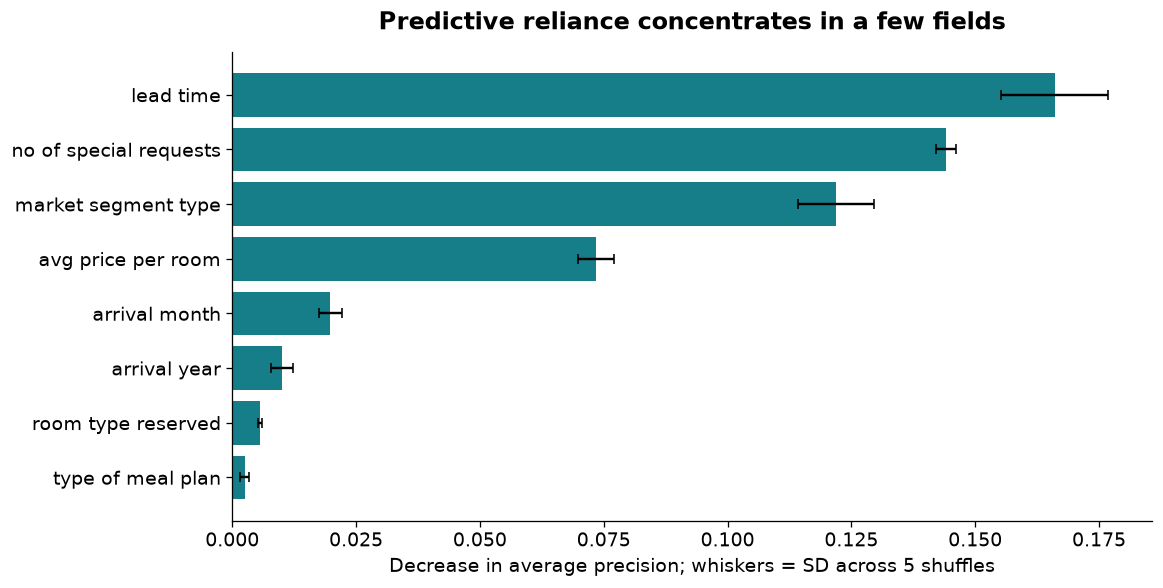

,feature,AP_decrease,repeat_sd
7,lead_time,0.1661,0.0108
16,no_of_special_requests,0.1440,0.0020
11,market_segment_type,0.1219,0.0077
15,avg_price_per_room,0.0735,0.0036
9,arrival_month,0.0198,0.0024
8,arrival_year,0.0100,0.0021
6,room_type_reserved,0.0057,0.0004
4,type_of_meal_plan,0.0025,0.0009


In [10]:
inspection_rows = X_val.sample(n=min(3000, len(X_val)), random_state=SEED).index
importance = permutation_importance(best, X_val.loc[inspection_rows], y_val.loc[inspection_rows],
    scoring='average_precision', n_repeats=5, random_state=SEED, n_jobs=1)
feature_importance = pd.DataFrame({'feature': X.columns,
    'AP_decrease': importance.importances_mean,
    'repeat_sd': importance.importances_std}).sort_values('AP_decrease', ascending=False)
top = feature_importance.head(8).sort_values('AP_decrease')
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.barh(top.feature.str.replace('_', ' '), top.AP_decrease,
        xerr=top.repeat_sd, color=COLORS['teal'], capsize=3)
ax.axvline(0, color=COLORS['gray'], lw=1)
ax.set_xlabel('Decrease in average precision; whiskers = SD across 5 shuffles')
ax.set_title('Predictive reliance concentrates in a few fields')
finish(fig, '08_feature_importance.png')
display(feature_importance.head(8).round(4))

,variant,mean_AP,sd_AP
0,all features,0.830374,0.002447
1,without derived features,0.831504,0.002311
2,without timing-uncertain fields,0.760550,0.006333


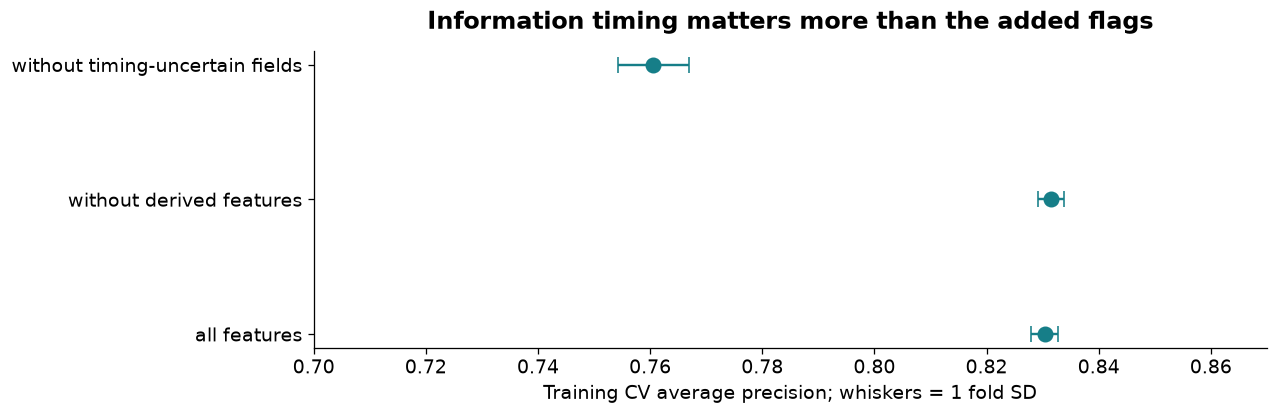

In [11]:
derived = ['total_guests', 'total_nights', 'invalid_arrival_date',
           'zero_guests', 'zero_nights', 'zero_room_price']
uncertain = ['no_of_previous_cancellations',
             'no_of_previous_bookings_not_canceled', 'no_of_special_requests']
sensitivity_rows = []
for name, drop in [('all features', []), ('without derived features', derived),
                   ('without timing-uncertain fields', uncertain)]:
    subset = X_fit.drop(columns=drop)
    result = cross_validate(make_model(estimators[winner], subset.columns),
        subset, y_fit, cv=cv, scoring='average_precision', n_jobs=1)
    sensitivity_rows.append({'variant': name, 'mean_AP': result['test_score'].mean(),
                              'sd_AP': result['test_score'].std(ddof=1)})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)
sensitivity.to_csv(OUT / 'training_sensitivity.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.errorbar(sensitivity.mean_AP, np.arange(len(sensitivity)), xerr=sensitivity.sd_AP,
            fmt='o', capsize=5, color=COLORS['teal'], markersize=9)
ax.set_yticks(np.arange(len(sensitivity)), sensitivity.variant)
ax.set_xlim(.70,.87)
ax.set_xlabel('Training CV average precision; whiskers = 1 fold SD')
ax.set_title('Information timing matters more than the added flags')
finish(fig, '09_feature_sensitivity.png')

**Interpretation.** The previous run found negligible benefit from the six derived fields and a substantial loss in AP after removing historical counts and special requests. These experiments test feature sets with the same model family and hyperparameters. They do not identify leakage or establish that a differently tuned reduced model could not improve.

**Code explanation.** Each variant constructs a new pipeline on its remaining columns. Training-fold metrics evaluate the diagnostic comparison. Neither the final holdout nor a claim about causality determines which fields are retained here.

## 10. Fixed-policy holdout performance and uncertainty

The original model and 5:1 validation-selected threshold remain fixed. The holdout comparison shows their workload and error tradeoff against a default cutoff and a prevalence-only baseline.

**Interpretive boundary:** this repeats the previously inspected holdout evaluation. It estimates performance on these reserved observations, with prior exploratory influence acknowledged. It is not independent replication.

,accuracy,precision,recall,F1,ROC_AUC,AP,Brier,alert_rate,TN,FP,FN,TP,illustrative_loss
dummy at 0.5,0.607957,0.000000,0.000000,0.000000,0.500000,0.392043,0.238345,0.000000,5119.0,0.0,3301.0,0.0,16505.0
selected model at 0.5,0.811401,0.780360,0.722205,0.750157,0.888217,0.835185,0.132696,0.362827,4448.0,671.0,917.0,2384.0,5256.0
selected model at chosen threshold,0.728979,0.598188,0.940321,0.731213,0.888217,0.835185,0.132696,0.616271,3034.0,2085.0,197.0,3104.0,3070.0


,policy,loss_units
0,alert nobody,16505
1,alert everybody,5119
2,chosen model threshold,3070


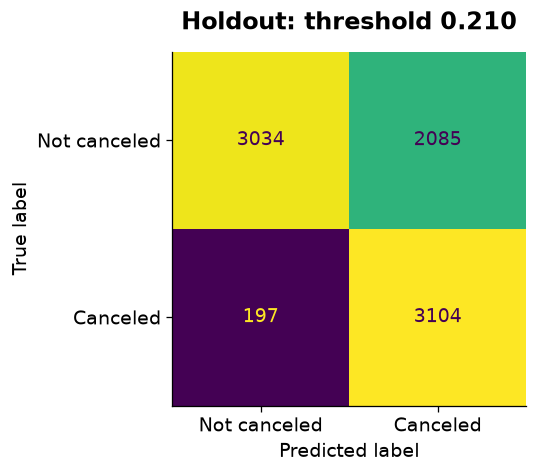

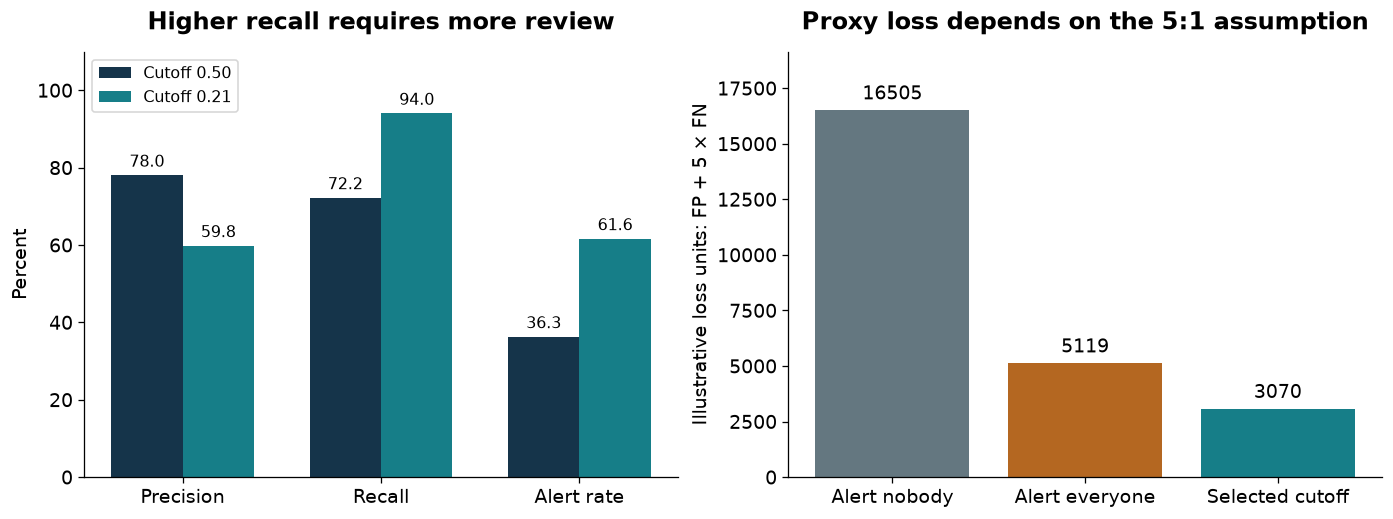

In [12]:
p_hold = best.predict_proba(X_hold)[:, 1]
dummy = make_model(estimators['Dummy'], X.columns).fit(X_fit, y_fit)
holdout = pd.DataFrame({
    'dummy at 0.5': metric_row(y_hold, dummy.predict_proba(X_hold)[:, 1]),
    'selected model at 0.5': metric_row(y_hold, p_hold),
    'selected model at chosen threshold': metric_row(y_hold, p_hold, threshold),
}).T
holdout['illustrative_loss'] = holdout.FP + 5 * holdout.FN
display(holdout)
holdout.to_csv(OUT / 'final_holdout_metrics.csv')
policy_baselines = pd.DataFrame({
    'policy': ['alert nobody', 'alert everybody', 'chosen model threshold'],
    'loss_units': [5 * int(y_hold.sum()), int((y_hold == 0).sum()),
                   int(holdout.loc['selected model at chosen threshold', 'illustrative_loss'])],
})
display(policy_baselines)
policy_baselines.to_csv(OUT / 'holdout_policy_comparison.csv', index=False)
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_hold, p_hold >= threshold,
    display_labels=['Not canceled', 'Canceled'], ax=ax, colorbar=False)
ax.set_title(f'Holdout: threshold {threshold:.3f}')
fig.savefig(OUT / 'holdout_confusion_matrix.png', dpi=160)
plt.show()



policies = holdout.loc[['selected model at 0.5', 'selected model at chosen threshold']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
xx = np.arange(3)
for i, (name, row) in enumerate(policies.iterrows()):
    values = row[['precision', 'recall', 'alert_rate']].to_numpy(dtype=float)*100
    bars = axes[0].bar(xx+(i-.5)*.36, values, width=.36,
        label='Cutoff 0.50' if i==0 else f'Cutoff {threshold:.2f}',
        color=COLORS['navy'] if i==0 else COLORS['teal'])
    axes[0].bar_label(bars, fmt='%.1f', fontsize=10, padding=3)
axes[0].set_xticks(xx, ['Precision', 'Recall', 'Alert rate'])
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Percent')
axes[0].set_title('Higher recall requires more review')
axes[0].legend(loc='upper left', fontsize=10)
bars = axes[1].bar(['Alert nobody', 'Alert everyone', 'Selected cutoff'], policy_baselines.loss_units,
                  color=[COLORS['gray'], COLORS['amber'], COLORS['teal']])
axes[1].bar_label(bars, padding=4, fmt='%.0f')
axes[1].set_ylim(0, policy_baselines.loss_units.max()*1.16)
axes[1].set_ylabel('Illustrative loss units: FP + 5 × FN')
axes[1].set_title('Proxy loss depends on the 5:1 assumption')
finish(fig, '10_holdout_policy_comparison.png')

,lower_95,upper_95
ROC_AUC,0.880976,0.894964
AP,0.821865,0.847137


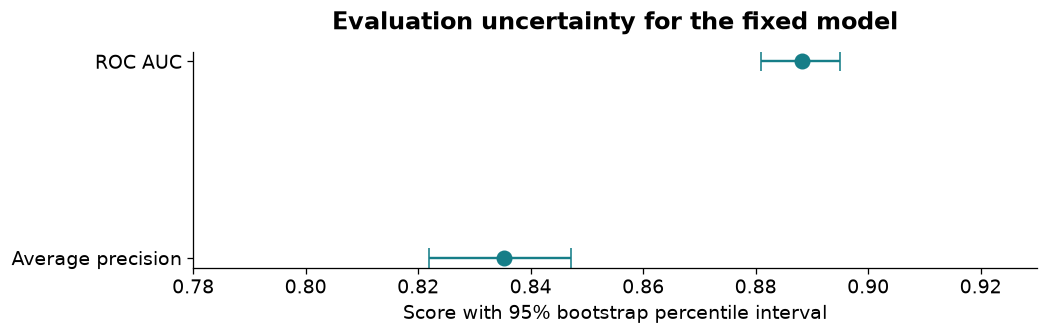

In [13]:
# Bootstrap uncertainty for ranking performance of this fixed fitted model.
# Does not include training uncertainty or correct prior exploration bias.
rng = np.random.default_rng(SEED)
labels = y_hold.to_numpy()
boot = []
for _ in range(500):
    idx = rng.integers(0, len(labels), size=len(labels))
    if np.unique(labels[idx]).size == 2:
        boot.append([roc_auc_score(labels[idx], p_hold[idx]),
                     average_precision_score(labels[idx], p_hold[idx])])
intervals = pd.DataFrame(np.quantile(boot, [0.025, 0.975], axis=0).T,
                         index=['ROC_AUC', 'AP'], columns=['lower_95', 'upper_95'])
display(intervals)
intervals.to_csv(OUT / 'holdout_bootstrap_intervals.csv')

fig, ax = plt.subplots(figsize=(9, 2.8), constrained_layout=True)
points = np.array([roc_auc_score(y_hold, p_hold), average_precision_score(y_hold, p_hold)])
ax.errorbar(points, [1,0],
    xerr=[points-intervals.lower_95.to_numpy(), intervals.upper_95.to_numpy()-points],
    fmt='o', capsize=6, markersize=9, color=COLORS['teal'])
ax.set_yticks([1,0], ['ROC AUC', 'Average precision'])
ax.set_xlim(.78,.93)
ax.set_xlabel('Score with 95% bootstrap percentile interval')
ax.set_title('Evaluation uncertainty for the fixed model')
finish(fig, '11_bootstrap_intervals.png')

**Code explanation.** `metric_row` separates threshold-dependent metrics from probability-based metrics. `.T` places policies in rows. The bootstrap resamples holdout row positions with replacement 500 times, always keeping each outcome paired with its probability. The 2.5th and 97.5th percentiles form the interval.

**Limitations.** The bootstrap assumes independent exchangeable rows. It holds the model fixed and does not capture training variability, model-selection uncertainty, prior EDA influence or distribution shift. A lower loss under the proxy does not demonstrate economic benefit.

## 11. Generalization across arrival years

The stress test uses valid-date 2017 arrivals to fit the already selected model family and valid-date 2018 arrivals to evaluate it. It changes the training sample size and outcome prevalence, so it cannot isolate a pure time effect.

Arrival dates are planned dates. A genuine deployment backtest would require booking timestamps, feature histories and the times when cancellation labels became available.

,accuracy,precision,recall,F1,ROC_AUC,AP,Brier,alert_rate,TN,FP,FN,TP,training_rows,evaluation_rows,training_cancellation_rate,evaluation_cancellation_rate,invalid_dates_excluded
0,0.668231,0.770469,0.32007,0.452261,0.769996,0.707588,0.206174,0.177773,19126,1469,10475,4931,6049,36001,0.179368,0.427933,50


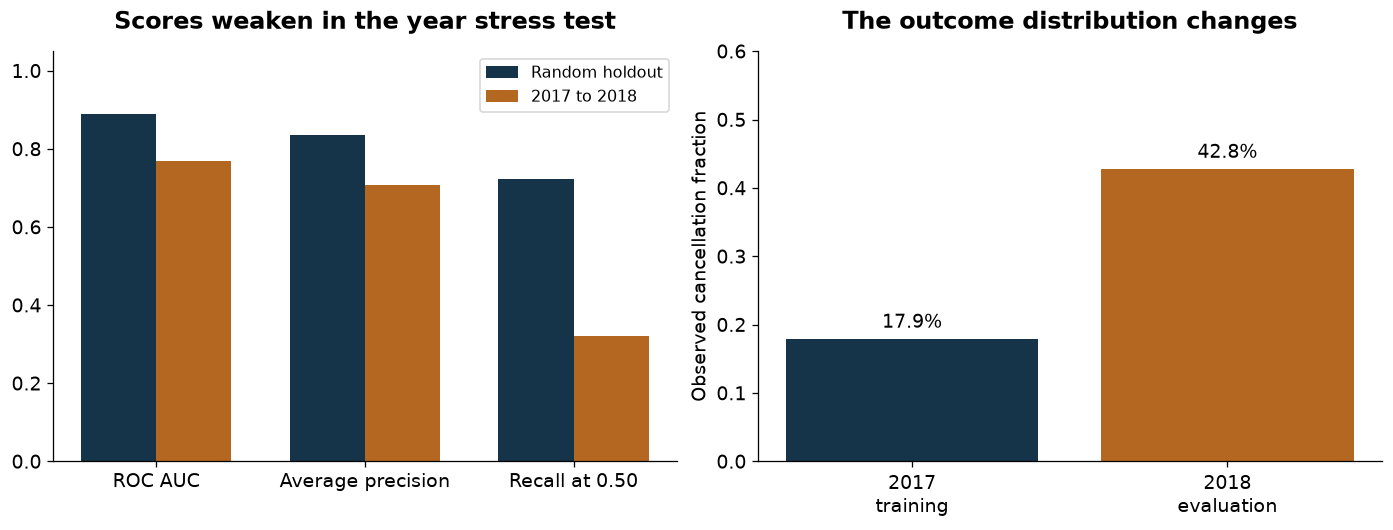

In [14]:
arrival = pd.to_datetime({'year': train.arrival_year, 'month': train.arrival_month,
                         'day': train.arrival_date}, errors='coerce')
early = arrival.notna() & train.arrival_year.eq(2017)
later = arrival.notna() & train.arrival_year.eq(2018)
year_model = make_model(estimators[winner], X.columns).fit(X.loc[early], y.loc[early])
p_later = year_model.predict_proba(X.loc[later])[:, 1]
year_stress = pd.DataFrame([metric_row(y.loc[later], p_later, 0.5)])
year_stress['training_rows'] = int(early.sum())
year_stress['evaluation_rows'] = int(later.sum())
year_stress['training_cancellation_rate'] = y.loc[early].mean()
year_stress['evaluation_cancellation_rate'] = y.loc[later].mean()
year_stress['invalid_dates_excluded'] = int(arrival.isna().sum())
display(year_stress)
year_stress.to_csv(OUT / 'arrival_year_stress_test.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
metric_names = ['ROC AUC', 'Average precision', 'Recall at 0.50']
random_values = [roc_auc_score(y_hold, p_hold), average_precision_score(y_hold, p_hold),
                 recall_score(y_hold, p_hold>=.5)]
year_values = [year_stress.ROC_AUC.iloc[0], year_stress.AP.iloc[0], year_stress.recall.iloc[0]]
xx = np.arange(3)
axes[0].bar(xx-.18, random_values, .36, label='Random holdout', color=COLORS['navy'])
axes[0].bar(xx+.18, year_values, .36, label='2017 to 2018', color=COLORS['amber'])
axes[0].set_xticks(xx, metric_names)
axes[0].set_ylim(0,1.05)
axes[0].set_title('Scores weaken in the year stress test')
axes[0].legend(fontsize=10)
prev = [y.loc[early].mean(), y.loc[later].mean()]
bars = axes[1].bar(['2017\ntraining', '2018\nevaluation'], prev, color=[COLORS['navy'], COLORS['amber']])
axes[1].bar_label(bars, labels=[f'{v:.1%}' for v in prev], padding=4)
axes[1].set_ylim(0,.6)
axes[1].set_ylabel('Observed cancellation fraction')
axes[1].set_title('The outcome distribution changes')
finish(fig, '12_year_stress_test.png')

**Interpretation.** The earlier analysis reported ROC AUC declining from 0.888 to 0.770 and recall at 0.50 declining from 72.2% to 32.0%. This limits the deployment claim. AP also depends on prevalence, so its cross-population comparison needs context.

**Code explanation.** Invalid dates become `NaT`. Boolean masks select valid 2017 and 2018 rows. A fresh pipeline trains only on the earlier subset. This experiment reuses rows from the original random split and is a stress test rather than independent confirmation.

## 12. Recommendation and prospective evaluation

**Recommendation:** test a confirmation-contact policy on genuinely new reservations after resolving feature timing and staffing constraints. Predictive ranking is promising within this file, but the observed workload and year shift argue for staged validation.

| Proposed stage | Required evidence | Decision before progressing |
|---|---|---|
| Data readiness | Timestamped feature snapshots and eventual outcomes | Every input exists at the declared scoring time |
| Silent prospective scoring | New-data precision, recall, reliability and workload | Predefined performance and capacity criteria hold |
| Randomized contact pilot | Contact versus usual-practice outcomes among eligible bookings | Estimate incremental benefit and guest impact |
| Operational review | Net benefit, uncertainty, workload and drift | Expand only if predeclared criteria are met |

For a randomized pilot, let $Y(1)$ denote cancellation under contact and $Y(0)$ under usual practice. The eligible-cohort effect is

$$\Delta=E[Y(1)-Y(0)].$$

The current model estimates observed cancellation risk. It does **not** estimate $\Delta$. No treatment-effect estimate or revenue-saving claim follows from the classification metrics.

### Explicit assumption register

| Assumption | Current evidence | Consequence if false | Proposed check |
|---|---|---|---|
| Features exist when scored | Unverified histories | Leakage or unavailable predictors | Audit timestamped snapshots |
| Synthetic patterns transfer | No real-hotel external validation | Lower future performance | New prospective cohort |
| Five-to-one error penalty is appropriate | Illustrative only | Unsuitable threshold and workload | Elicit actual costs and constraints |
| High-risk guests benefit from contact | No intervention data | Accurate alerts without benefit | Randomized pilot |
| Records are sufficiently independent | No guest/group identifier audit | Optimistic uncertainty | Audit grouping and use grouped evaluation |
| Staff can act on the selected alerts | No capacity measurement | Operational overload | Measure daily eligible volume and handling time |

### Graduate-level discussion

1. Why might a model with strong ROC AUC still produce little economic value?
2. How would clustered guests or changing booking channels alter the validation design?
3. What evidence would justify replacing the random split with an event-time backtest?
4. If outreach benefits low-risk guests more, should risk ranking determine whom to contact?

## Methods appendix and assignment alignment

| Assignment criterion | Notebook evidence |
|---|---|
| Relevant data | Source, synthetic provenance, unit of analysis and target |
| Cleansing and transformation | Reproduced totals, anomaly flags and category handling |
| Pattern discovery | Lead-time comparison, uncertainty and multivariable inspection |
| Visualization | Comparisons of models, thresholds, capacity and period performance |
| Predictive modeling | Logistic regression, decision tree and random forest with baseline |
| Actionable recommendation | Explicit assumptions, workload analysis and prospective pilot |

At least one modeling method must match material covered in the course. Maintain an honest contribution log and satisfy the assignment's stated 30-hour minimum per member. Every member should understand the full analysis.

**Model settings.** Logistic regression: `C=1`, `max_iter=3000`. Decision tree: `max_depth=6`, `min_samples_leaf=30`. Random forest: 150 trees, `min_samples_leaf=5`, `max_features='sqrt'`. All random operations use seed 42 where supported. Scaling and imputation fit within folds. No competition test data enter model selection.

**Source lineage.** Project files: `00_data_preparation.ipynb`, `01_data_audit_and_eda.ipynb`, `reports/analysis_handoff.md`, `README.md`, and the companion modeling workflow. The original assignment is `Project Assignment Description.docx`.

**References**

1. [Kaggle Playground Series S3E7 data](https://www.kaggle.com/competitions/playground-series-s3e7/data). Dataset provenance follows the project's recorded source documentation.
2. [scikit-learn pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html). Fold-specific preprocessing.
3. [scikit-learn probability calibration](https://scikit-learn.org/stable/modules/calibration.html). Reliability and probability scoring.
4. [scikit-learn threshold tuning](https://scikit-learn.org/1.5/modules/classification_threshold.html). Separate probability prediction from the action rule.
5. [scikit-learn permutation importance with correlated features](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html). Limits of individual-feature attribution.

In [15]:
# Export compact results for the report; fitted estimators are not serialized here.
feature_importance.to_csv(OUT/'feature_importance.csv', index=False)
scenario.to_csv(OUT/'cost_sensitivity.csv', index=False)
run_summary = {'selected_model': winner, 'fixed_validation_threshold': threshold,
               'holdout_ROC_AUC': roc_auc_score(y_hold, p_hold),
               'holdout_AP': average_precision_score(y_hold, p_hold),
               'FN_penalty': 5, 'FP_penalty': 1,
               'interpretation': 'Synthetic retrospective evidence; no estimated intervention benefit.'}
(OUT/'run_summary.json').write_text(json.dumps(run_summary, indent=2))
display(pd.Series(run_summary, name='Run summary').to_frame())

,Run summary
selected_model,Random forest
fixed_validation_threshold,0.21
holdout_ROC_AUC,0.888217
holdout_AP,0.835185
FN_penalty,5
FP_penalty,1
interpretation,Synthetic retrospective evidence; no estimated...
